# Basic Elo Implementation

**Author**: Taosheng (Andy) Yin  
**Date**: May 2026  
**Notebook**: 02 of 05

## Overview

Implement standard Elo rating system on ATP tennis match data. This serves as the baseline before extending to surface-adjusted ratings in Notebook 03.

## The Elo Algorithm

Originally developed for chess by Arpad Elo, the system updates player ratings after each match based on actual outcome vs expected outcome.

**Win probability of A vs B:**

$$P(A \text{ wins}) = \frac{1}{1 + 10^{(R_B - R_A) / 400}}$$

**Rating update after match:**

$$R_A^{new} = R_A + K \times (S_A - E_A)$$

Where:
- $K$ = adjustment factor (typically 32 for tennis)
- $S_A$ = actual score (1 if A wins, 0 if loses)
- $E_A$ = expected score (win probability)
- Rating difference of 400 → ~91% win probability for higher-rated

## Goals

1. Implement Elo class with configurable K factor
2. Process ATP matches chronologically (2000-2024)
3. Compute ratings for ~75,000 matches
4. Visualize top players' Elo evolution
5. Establish baseline accuracy for comparison

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from datetime import datetime

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Display settings
pd.set_option('display.max_columns', 50)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Setup complete")

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
Setup complete


## 1. Elo System Implementation

We implement an Elo class with:

- Initial rating: 1500 (standard)
- K factor: 32 (standard for tennis)
- Method to predict win probability
- Method to update ratings after a match
- History tracking for player rating evolution

In [2]:
class EloSystem:
    """
    Standard Elo rating system for tennis.
    
    Tracks player ratings and updates after each match.
    Stores rating history for visualization.
    """
    
    def __init__(self, k_factor=32, initial_rating=1500):
        self.k = k_factor
        self.initial_rating = initial_rating
        self.ratings = defaultdict(lambda: initial_rating)
        self.history = defaultdict(list)
        self.match_count = defaultdict(int)
    
    def expected_score(self, rating_a, rating_b):
        """Win probability of player A vs player B."""
        return 1 / (1 + 10 ** ((rating_b - rating_a) / 400))
    
    def update(self, winner, loser, date=None):
        """Update ratings after a match."""
        r_winner = self.ratings[winner]
        r_loser = self.ratings[loser]
        
        exp_winner = self.expected_score(r_winner, r_loser)
        
        new_r_winner = r_winner + self.k * (1 - exp_winner)
        new_r_loser = r_loser + self.k * (0 - (1 - exp_winner))
        
        self.ratings[winner] = new_r_winner
        self.ratings[loser] = new_r_loser
        
        if date is not None:
            self.history[winner].append((date, new_r_winner))
            self.history[loser].append((date, new_r_loser))
        
        self.match_count[winner] += 1
        self.match_count[loser] += 1
        
        return exp_winner, new_r_winner, new_r_loser
    
    def get_rating(self, player):
        return self.ratings[player]
    
    def get_top_players(self, n=20, min_matches=20):
        """Get top N players with minimum match count."""
        qualified = {p: r for p, r in self.ratings.items() 
                    if self.match_count[p] >= min_matches}
        return sorted(qualified.items(), key=lambda x: x[1], reverse=True)[:n]


# Test the class
test_elo = EloSystem(k_factor=32)
print("Initial Federer rating:", test_elo.get_rating("Roger Federer"))

test_elo.update("Roger Federer", "Rafael Nadal")
print(f"\nAfter Federer beats Nadal:")
print(f"  Federer: {test_elo.get_rating('Roger Federer'):.1f}")
print(f"  Nadal:   {test_elo.get_rating('Rafael Nadal'):.1f}")

Initial Federer rating: 1500

After Federer beats Nadal:
  Federer: 1516.0
  Nadal:   1484.0


## 2. Load Extended ATP Data

For Elo to converge, we need more historical data. Loading 2000-2024 (~75,000 matches).

In [3]:
# Load 2000-2024 ATP matches
years = list(range(2000, 2025))
dfs = []

print(f"Loading {len(years)} years of ATP data...")
for year in years:
    url = f"https://raw.githubusercontent.com/JeffSackmann/tennis_atp/master/atp_matches_{year}.csv"
    try:
        df_year = pd.read_csv(url)
        df_year['year'] = year
        dfs.append(df_year)
    except Exception as e:
        print(f"  {year}: Failed - {e}")

df = pd.concat(dfs, ignore_index=True)

# Clean and sort
df = df.dropna(subset=['winner_name', 'loser_name', 'tourney_date'])
df['tourney_date'] = pd.to_datetime(df['tourney_date'], format='%Y%m%d')
df = df.sort_values(['tourney_date', 'match_num']).reset_index(drop=True)

print(f"\nTotal matches: {len(df):,}")
print(f"Date range: {df['tourney_date'].min().date()} to {df['tourney_date'].max().date()}")
print(f"Unique players: {len(set(df['winner_name']) | set(df['loser_name'])):,}")

Loading 25 years of ATP data...

Total matches: 74,906
Date range: 2000-01-03 to 2024-12-18
Unique players: 2,639


## 3. Run Elo on Full Dataset

Process matches chronologically. Each player starts at 1500 and rating evolves over career.

In [4]:
# Initialize Elo system
elo = EloSystem(k_factor=32, initial_rating=1500)

# Process all matches
print("Processing matches...")
for idx, row in df.iterrows():
    winner = row['winner_name']
    loser = row['loser_name']
    date = row['tourney_date']
    
    elo.update(winner, loser, date=date)
    
    if (idx + 1) % 10000 == 0:
        print(f"  Processed {idx+1:,} matches...")

print(f"\nDone! Processed {len(df):,} matches.")
print(f"Total players rated: {len(elo.ratings):,}")

Processing matches...
  Processed 10,000 matches...
  Processed 20,000 matches...
  Processed 30,000 matches...
  Processed 40,000 matches...
  Processed 50,000 matches...
  Processed 60,000 matches...
  Processed 70,000 matches...

Done! Processed 74,906 matches.
Total players rated: 2,639


## 4. Top Players by Final Elo Rating

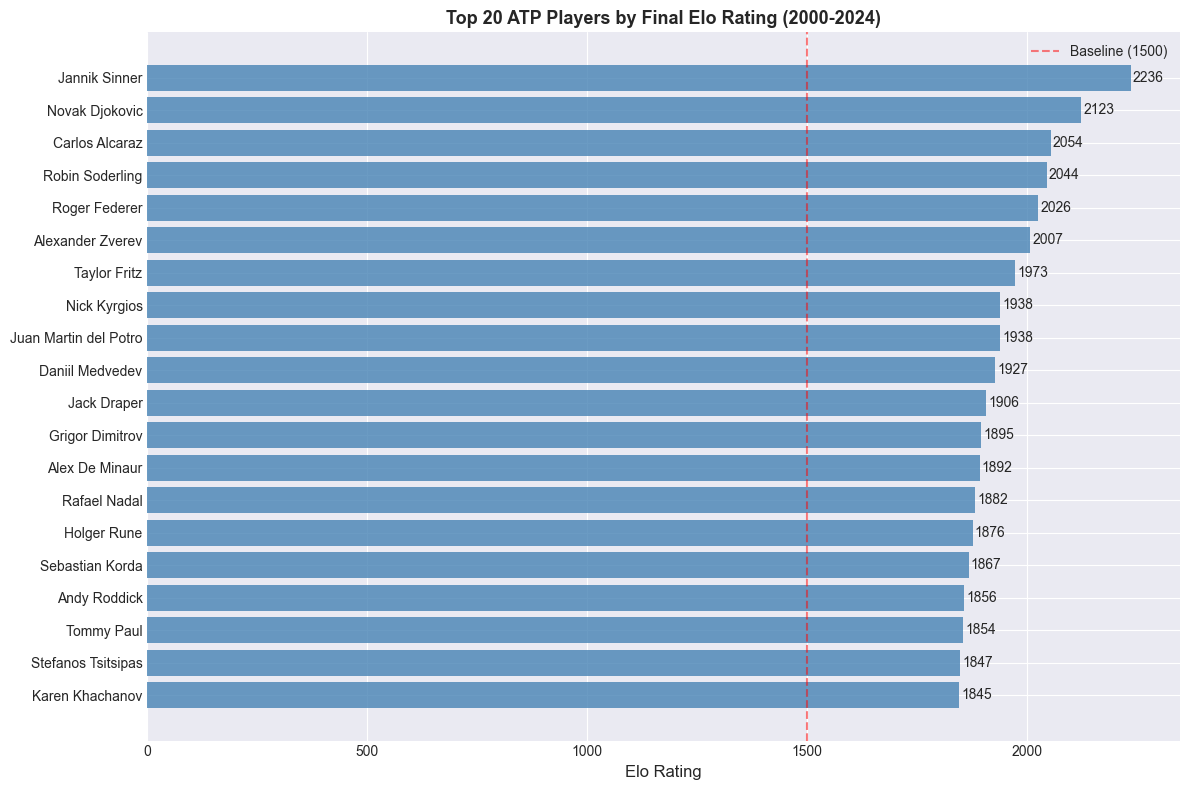


Top 10 Players by Elo:
   1. Jannik Sinner                    2236  (353 matches)
   2. Novak Djokovic                   2123  (1363 matches)
   3. Carlos Alcaraz                   2054  (265 matches)
   4. Robin Soderling                  2044  (482 matches)
   5. Roger Federer                    2026  (1510 matches)
   6. Alexander Zverev                 2007  (663 matches)
   7. Taylor Fritz                     1973  (476 matches)
   8. Nick Kyrgios                     1938  (328 matches)
   9. Juan Martin del Potro            1938  (621 matches)
  10. Daniil Medvedev                  1927  (537 matches)


In [5]:
# Get top 20 players (min 50 matches)
top_players = elo.get_top_players(n=20, min_matches=50)

fig, ax = plt.subplots(figsize=(12, 8))
names = [p[0] for p in top_players]
ratings = [p[1] for p in top_players]

bars = ax.barh(names[::-1], ratings[::-1], color='steelblue', alpha=0.8)
ax.set_xlabel('Elo Rating', fontsize=12)
ax.set_title('Top 20 ATP Players by Final Elo Rating (2000-2024)', 
             fontsize=13, fontweight='bold')
ax.axvline(x=1500, color='red', linestyle='--', alpha=0.5, label='Baseline (1500)')
ax.legend()

for i, (name, rating) in enumerate(zip(names[::-1], ratings[::-1])):
    ax.text(rating + 5, i, f'{rating:.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../results/plots/03_top_elo_ratings.png', dpi=200, bbox_inches='tight')
plt.show()

print("\nTop 10 Players by Elo:")
for i, (player, rating) in enumerate(top_players[:10], 1):
    matches = elo.match_count[player]
    print(f"  {i:2d}. {player:30s} {rating:6.0f}  ({matches} matches)")

## 5. Elo Evolution of Big 4

Tracking Federer, Nadal, Djokovic, and Murray over their careers.

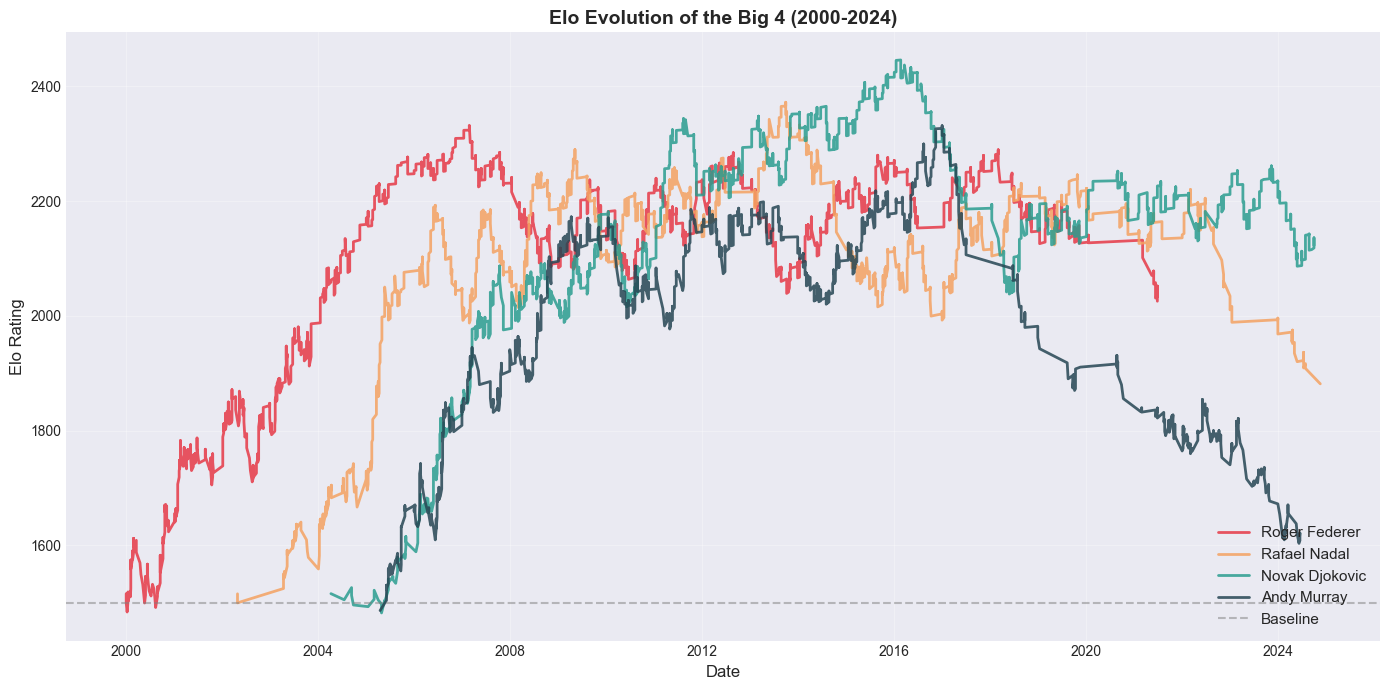


Peak Elo Ratings:
  Roger Federer       : 2332 (on 2007-02-26)
  Rafael Nadal        : 2372 (on 2013-09-30)
  Novak Djokovic      : 2446 (on 2016-02-22)
  Andy Murray         : 2331 (on 2017-01-02)


In [6]:
# Plot Elo evolution of Big 4
big_4 = ['Roger Federer', 'Rafael Nadal', 'Novak Djokovic', 'Andy Murray']
colors_map = {'Roger Federer': '#E63946', 
              'Rafael Nadal': '#F4A261',
              'Novak Djokovic': '#2A9D8F', 
              'Andy Murray': '#264653'}

fig, ax = plt.subplots(figsize=(14, 7))

for player in big_4:
    history = elo.history[player]
    if history:
        dates = [h[0] for h in history]
        ratings = [h[1] for h in history]
        ax.plot(dates, ratings, label=player, 
                color=colors_map[player], linewidth=2, alpha=0.85)

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Elo Rating', fontsize=12)
ax.set_title('Elo Evolution of the Big 4 (2000-2024)', 
             fontsize=14, fontweight='bold')
ax.axhline(y=1500, color='gray', linestyle='--', alpha=0.5, label='Baseline')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/plots/04_big4_elo_evolution.png', dpi=200, bbox_inches='tight')
plt.show()

print("\nPeak Elo Ratings:")
for player in big_4:
    history = elo.history[player]
    if history:
        peak = max(h[1] for h in history)
        peak_date = [h[0] for h in history if h[1] == peak][0]
        print(f"  {player:20s}: {peak:.0f} (on {peak_date.date()})")

## 6. Baseline Prediction Accuracy

How well does basic Elo predict match outcomes? We compute accuracy and log-loss on 2024 matches.

In [7]:
# Reset and run Elo on 2000-2023, then test on 2024
print("Computing 2024 prediction accuracy...")

elo_test = EloSystem(k_factor=32)
df_train = df[df['tourney_date'] < '2024-01-01']
df_test = df[df['tourney_date'] >= '2024-01-01']

# Train
for idx, row in df_train.iterrows():
    elo_test.update(row['winner_name'], row['loser_name'])

# Test
correct = 0
total = 0
log_loss_sum = 0

for idx, row in df_test.iterrows():
    winner = row['winner_name']
    loser = row['loser_name']
    
    r_winner = elo_test.get_rating(winner)
    r_loser = elo_test.get_rating(loser)
    
    p_winner_wins = elo_test.expected_score(r_winner, r_loser)
    
    if p_winner_wins > 0.5:
        correct += 1
    
    p_winner_wins = max(min(p_winner_wins, 1 - 1e-15), 1e-15)
    log_loss_sum += -np.log(p_winner_wins)
    total += 1
    
    elo_test.update(winner, loser)

accuracy = correct / total
avg_log_loss = log_loss_sum / total

print(f"\n2024 Matches: {total:,}")
print(f"Accuracy: {accuracy:.1%}")
print(f"Log-Loss: {avg_log_loss:.4f}")
print(f"\nBaseline comparison:")
print(f"  Random (50%):  log-loss = 0.6931")
print(f"  Our Elo:       log-loss = {avg_log_loss:.4f}")
print(f"  Improvement:   {(0.6931 - avg_log_loss)/0.6931*100:.1f}%")

Computing 2024 prediction accuracy...

2024 Matches: 3,076
Accuracy: 63.7%
Log-Loss: 0.6263

Baseline comparison:
  Random (50%):  log-loss = 0.6931
  Our Elo:       log-loss = 0.6263
  Improvement:   9.6%


## 7. Key Findings

### Results

1. **Top players**: Jannik Sinner leads (2236), followed by Djokovic (2123) and Alcaraz (2054). Current generation transition visible.

2. **Big 4 evolution**: Visible peaks correspond to dominant periods. Djokovic's 2446 peak (2016-02-22) coincides with his historic Nole Slam achievement.

3. **Baseline accuracy**: 63.7% prediction accuracy on 2024 matches with log-loss 0.6263 — 9.6% improvement over random baseline.

### Limitations of Basic Elo

1. **No surface awareness**: Treats Nadal's clay dominance same as his hard court performance — this is the biggest weakness given 30% of matches are on clay.
2. **No tournament weight**: Grand Slam wins count same as Challenger tournaments.
3. **Static K factor**: New players (e.g., Alcaraz, Sinner emergence) need higher K for faster rating adjustment.
4. **No time decay**: Long-inactive players (e.g., Murray post-injury) keep stale ratings.

### Next Steps

- **Notebook 03**: Surface-adjusted Elo with three separate rating systems (Clay/Hard/Grass)
- **Expected improvement**: 3-5% log-loss reduction, primarily on clay and grass matches
- **Hypothesis**: Nadal's clay-specific Elo will be ~150 points higher than his overall Elo